# Phase 5/7 — Notebook 26: Benign-Only Monitor Reference (the trigger false-alarm fix)

**Notebook:** `notebooks/07_phase5_adaptation/26_benign_reference_trigger.ipynb`
**Pre-registration:** `PREREG_addendum_A3_benign_reference.md` — commit (date + git hash) BEFORE running.

**The artifact (A3.1).** nb20–22's quiet-window false alarms are an *initialization
composition artifact*: the quiet stretch is benign-only while the monitor's initial
reference and calibration are the mixed warm-up (benign + SEEN). Because the
triggered policy's reference updates onto the last fired window, the monitor fires
on early quiet windows, resets onto benign data, then goes silent.

**The fix (A3.2).** Decouple the monitor's data from the detector's warm-up: the
detector still trains on benign + SEEN (unchanged); the monitor's initial reference
and calibration become **benign-only** (halves of the warm-up's benign rows).
`KSMonitor` / `run_instrumented` / policies are byte-identical — this is a
call-site change only, preserving comparability with nb18–22.

**Design (A3.3).** nb21's exact construction (breadths [1,2,4], window 5,000,
≥10 quiet windows, seed 42), two monitor arms on identical streams and identical
detectors: **control** (nb21 verbatim, must reconcile with the stored nb21 summary)
vs **treatment** (benign-only). Calibration for the treatment uses N_CAL=10 seeded
bootstrap 5k-windows from the 12.5k benign calibration pool (too small for
contiguous windows), with a 2-contiguous-window sensitivity check reported.

**Gates (A3.4):** G-CTRL (control reproduces the artifact: quiet FA > 0.10 at ≥1
breadth) ∧ G-FA (treatment: point ≤ 0.10 and Wilson upper ≤ 0.20 at EVERY breadth)
∧ G-DET (onset latency ≤ 1 and treatment triggered_2500 recall ≥ control − 0.05 at
every breadth) → **ARTIFACT-FIXED**.

**Runtime:** ≈ nb21 + the extra triggered runs; expect 30–60 min on Colab.

## 1. Environment + pre-registered configuration

In [1]:
import sys
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except Exception:
    pass
THESIS_ROOT = Path('/content/drive/MyDrive/phd_thesis')
if str(THESIS_ROOT) not in sys.path:
    sys.path.insert(0, str(THESIS_ROOT))

import numpy as np, pandas as pd, json, time, math, glob, inspect
from datetime import date
import matplotlib.pyplot as plt

from src.utils.seeding import set_global_seed
from src.utils.io import path
from src.utils.documentation import log_finding
from src.streaming.replay import train_detector
from src.monitoring.ks_monitor import KSMonitor, per_feature_ks
from src.adaptation.cost_eval import run_instrumented, micro_metrics
assert 'always_cheap' in inspect.getsource(run_instrumented), \
    'cost_eval is not the v2; run the notebook-20 cell that writes it first.'

SEED = 42; set_global_seed(SEED)
RF_KW = dict(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)

# --- nb21 construction, verbatim (D039) ---
BREADTHS      = [1, 2, 4]
WINDOW_SIZE   = 5000
QUIET_WINDOWS = 10
TRAIN_BENIGN  = 25000
K_SIGMA, REF_FRAC = 3.0, 0.50

# --- A3 additions ---
N_CAL_BOOT = 10          # bootstrap calibration windows (benign pool = 12.5k)
L_MAX      = 1           # onset-latency gate
FA_POINT_MAX, FA_CI_MAX = 0.10, 0.20
RECALL_MARGIN = 0.05
print('Config set. Arms: control (nb21 mixed ref) vs treatment (benign-only ref).')

Mounted at /content/drive
Config set. Arms: control (nb21 mixed ref) vs treatment (benign-only ref).


## 2. Load UNSW (nb21's inline loader, verbatim)

In [2]:
def _find_unsw_files():
    pats = ['unsw*.parquet', 'UNSW*.parquet', '*unsw*.parquet']
    for sub in ('data/processed', 'data/interim', 'data/raw'):
        d = THESIS_ROOT / sub
        if not d.exists():
            continue
        hits = []
        for p in pats:
            hits += list(d.rglob(p))
        if hits:
            return ('parquet', sorted(set(hits)))
    for sub in ('data/raw', 'data/raw/unsw_nb15', 'data/raw/UNSW-NB15'):
        d = THESIS_ROOT / sub
        if d.exists():
            csvs = [c for c in sorted(d.rglob('*.csv')) if 'unsw' in c.name.lower()]
            if csvs:
                return ('csv', csvs)
    return (None, [])

def _pick(df, names):
    low = {c.lower(): c for c in df.columns}
    for nm in names:
        if nm.lower() in low:
            return low[nm.lower()]
    return None

kind, files = _find_unsw_files()
assert kind is not None, 'No UNSW parquet/csv found.'
df_raw = (pd.concat([pd.read_parquet(p) for p in files], ignore_index=True) if kind == 'parquet'
          else pd.concat([pd.read_csv(p, low_memory=False) for p in files], ignore_index=True))
cat_col = _pick(df_raw, ['attack_category', 'attack_cat', 'attackcat', 'category'])
lab_col = _pick(df_raw, ['label', 'Label', 'is_attack'])
id_like = [c for c in df_raw.columns if c.lower() in (
    'id', 'srcip', 'dstip', 'sport', 'dsport', 'stime', 'ltime', 'source_file', 'attempted')]
fams = df_raw[cat_col].astype(str).str.strip().str.lower().replace(
    {'': 'benign', 'normal': 'benign', 'nan': 'benign', '-': 'benign'})
feat = df_raw.drop(columns=[c for c in [cat_col, lab_col] + id_like if c], errors='ignore')
feat = feat.apply(pd.to_numeric, errors='coerce')
feat = feat.loc[:, feat.notna().mean() > 0.99].fillna(0.0).astype('float32')
X_all = feat.to_numpy(); fam = fams.to_numpy()
y_attack = (fam != 'benign').astype(int)
is_benign = (fam == 'benign')
attack_order = list(pd.Series(fam[y_attack == 1]).value_counts().index)
print(f'UNSW {kind}: {feat.shape[1]} features; attack rate {y_attack.mean():.3f}')
print('attack families (largest first):', attack_order)

UNSW parquet: 42 features; attack rate 0.639
attack families (largest first): ['generic', 'exploits', 'fuzzers', 'dos', 'reconnaissance', 'analysis', 'backdoor', 'shellcode', 'worms']


## 3. Helpers (nb21 verbatim) + the A3 benign-split addition

In [3]:
def windows_of(n, size):
    b = list(range(0, n, size)) + [n]
    return [(b[i], b[i + 1]) for i in range(len(b) - 1)]

def wilson(k, n, z=1.96):
    if n == 0:
        return (float('nan'), float('nan'))
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (max(0.0, c - h), min(1.0, c + h))

def build_regime(seen_fams):
    """nb21 verbatim, plus: returns the warm-up's benign row-positions so the
    treatment arm can carve its benign-only monitor splits from them."""
    novel_fams = [f for f in attack_order if f not in seen_fams]
    rng = np.random.default_rng(SEED)
    benign_idx = np.where(is_benign)[0]; rng.shuffle(benign_idx)
    seen_idx = np.where(np.isin(fam, seen_fams))[0]
    novel_idx = np.where(np.isin(fam, novel_fams))[0]; rng.shuffle(novel_idx)
    n_trb = min(TRAIN_BENIGN, len(benign_idx) // 2)
    warm = np.concatenate([benign_idx[:n_trb], seen_idx]); rng.shuffle(warm)
    Xtr, ytr = X_all[warm], y_attack[warm]
    warm_benign_pos = np.flatnonzero(y_attack[warm] == 0)   # positions within Xtr
    rest_benign = benign_idx[n_trb:]
    q_take = min(len(rest_benign), QUIET_WINDOWS * WINDOW_SIZE)
    quiet_rows = rest_benign[:q_take]; drift_benign = rest_benign[q_take:]
    n_fill = min(len(drift_benign), len(novel_idx))
    drift_rows = np.concatenate([novel_idx, drift_benign[:n_fill]]); rng.shuffle(drift_rows)
    stream_idx = np.concatenate([quiet_rows, drift_rows])
    Xs, ys, fam_s = X_all[stream_idx], y_attack[stream_idx], fam[stream_idx]
    wins = windows_of(len(Xs), WINDOW_SIZE)
    is_drift = [bool(np.isin(fam_s[a:b], novel_fams).any()) for (a, b) in wins]
    return dict(Xtr=Xtr, ytr=ytr, warm_benign_pos=warm_benign_pos,
                Xs=Xs, ys=ys, windows=wins, is_drift=is_drift, novel=novel_fams)

def calibrate_bootstrap(monitor, cal_pool, n_windows, win_size, k, seed):
    """A3.2: tau from seeded bootstrap windows (pool too small for contiguous)."""
    rng = np.random.default_rng(seed)
    wins = [cal_pool[rng.choice(len(cal_pool), size=min(win_size, len(cal_pool)),
                                replace=False)] for _ in range(n_windows)]
    return monitor.calibrate(wins, k=k)

print('helpers ready.')

helpers ready.


## 4. The two-arm sweep

Per breadth: build the regime once (identical stream + detector for both arms),
then run the triggered policies under the **control** monitor (nb21 verbatim:
mixed reference, contiguous mixed calibration) and the **treatment** monitor
(benign-only reference, bootstrap benign calibration + contiguous sensitivity
tau). `never` and `always_sliding` are monitor-independent and run once.

In [4]:
results = []
t0 = time.time()
for b in BREADTHS:
    seen = attack_order[:b]
    R = build_regime(seen)
    Xtr, ytr = R['Xtr'], R['ytr']
    Xs, ys, wins, is_drift = R['Xs'], R['ys'], R['windows'], R['is_drift']
    is_quiet = [not d for d in is_drift]
    quiet_idx = [i for i, q in enumerate(is_quiet) if q]
    onset = next(i for i, d in enumerate(is_drift) if d)
    det0 = train_detector(Xtr, ytr, RF_KW)

    # ---- control monitor: nb21 verbatim ----
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(Xtr)); n_ref = int(REF_FRAC * len(Xtr))
    REF_C, Xcal_C = Xtr[perm[:n_ref]], Xtr[perm[n_ref:]]
    mon_c = KSMonitor(REF_C)
    mon_c.calibrate([Xcal_C[a:b2] for (a, b2) in windows_of(len(Xcal_C), WINDOW_SIZE)],
                    k=K_SIGMA)

    # ---- treatment monitor: benign-only (A3.2) ----
    bpos = R['warm_benign_pos']
    rngb = np.random.default_rng(SEED)
    bperm = rngb.permutation(len(bpos))
    half = len(bpos) // 2
    REF_T = Xtr[bpos[bperm[:half]]]
    CAL_T = Xtr[bpos[bperm[half:]]]
    mon_t = KSMonitor(REF_T)
    cal_t = calibrate_bootstrap(mon_t, CAL_T, N_CAL_BOOT, WINDOW_SIZE, K_SIGMA, SEED)
    # sensitivity: contiguous 2-window tau (reported, not gated)
    mon_t2 = KSMonitor(REF_T)
    cal_t2 = mon_t2.calibrate([CAL_T[a:b2] for (a, b2)
                               in windows_of(len(CAL_T), WINDOW_SIZE)], k=K_SIGMA)

    # ---- shared, monitor-independent policies ----
    out_never = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='never')
    out_slide = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='always_sliding')

    arms = {}
    for arm, (REF_A, tau_A) in {'control': (REF_C, mon_c.tau),
                                'treatment': (REF_T, mon_t.tau)}.items():
        o250 = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='triggered',
                                reference0=REF_A, tau=tau_A, budget=250)
        o2500 = run_instrumented(Xs, ys, wins, det0, RF_KW, policy='triggered',
                                 reference0=REF_A, tau=tau_A, budget=2500)
        trg = sorted(o250['triggers'])
        fa_k = sum(1 for i in quiet_idx if i in set(trg)); fa_n = len(quiet_idx)
        lo, hi = wilson(fa_k, fa_n)
        first_drift_fire = next((i for i in trg if i >= onset), None)
        latency = (first_drift_fire - onset) if first_drift_fire is not None else None
        arms[arm] = dict(
            tau=float(tau_A), triggers=trg, fa_k=fa_k, fa_n=fa_n,
            fa_point=fa_k / fa_n if fa_n else float('nan'), fa_ci=(lo, hi),
            onset_latency=latency,
            recall_t2500=micro_metrics(o2500['per_window'], mask=is_drift)['recall'],
            recall_t250=micro_metrics(o250['per_window'], mask=is_drift)['recall'],
            labels_t250=o250['label_cost'])

    results.append(dict(
        breadth=b, seen=seen, novel=R['novel'], onset_window=onset,
        n_quiet=len(quiet_idx), n_drift=int(sum(is_drift)),
        never_recall=micro_metrics(out_never['per_window'], mask=is_drift)['recall'],
        slide_recall=micro_metrics(out_slide['per_window'], mask=is_drift)['recall'],
        tau_treatment_bootstrap=float(mon_t.tau),
        tau_treatment_contiguous=float(mon_t2.tau),
        cal_treatment=cal_t, arms=arms))
    a, c = arms['treatment'], arms['control']
    print(f"breadth {b}: control FA {c['fa_k']}/{c['fa_n']} CI[{c['fa_ci'][0]:.2f},{c['fa_ci'][1]:.2f}] "
          f"lat {c['onset_latency']} | treatment FA {a['fa_k']}/{a['fa_n']} "
          f"CI[{a['fa_ci'][0]:.2f},{a['fa_ci'][1]:.2f}] lat {a['onset_latency']} "
          f"| t2500 recall ctrl {c['recall_t2500']:.3f} vs treat {a['recall_t2500']:.3f} "
          f"({time.time()-t0:.0f}s)")

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 1: control FA 1/10 CI[0.02,0.40] lat 0 | treatment FA 2/10 CI[0.06,0.51] lat 0 | t2500 recall ctrl 0.868 vs treat 0.819 (14s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 2: control FA 1/10 CI[0.02,0.40] lat 0 | treatment FA 2/10 CI[0.06,0.51] lat 0 | t2500 recall ctrl 0.914 vs treat 0.887 (29s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_f

breadth 4: control FA 2/10 CI[0.06,0.51] lat 0 | treatment FA 3/10 CI[0.11,0.60] lat 0 | t2500 recall ctrl 0.842 vs treat 0.838 (41s)


## 5. Cross-check the control arm against the stored nb21 summary

The control arm re-runs nb21's monitor on nb21's construction; its FA counts
and triggered_2500 recalls should reconcile with the stored nb21 summary
(graceful skip if the file is named differently — then eyeball against the
nb21 notebook output instead).

In [5]:
hits = sorted(glob.glob(str(THESIS_ROOT / 'data' / 'processed' / '*21*unsw*.json'))) + \
       sorted(glob.glob(str(THESIS_ROOT / 'data' / 'processed' / '*unsw_hard*.json')))
if hits:
    with open(hits[0]) as f:
        j21 = json.load(f)
    print('nb21 summary found:', hits[0])
    per = {r['breadth']: r for r in j21.get('per_regime', [])}
    for r in results:
        ref = per.get(r['breadth'])
        if not ref:
            continue
        got = r['arms']['control']['recall_t2500']
        exp = ref.get('recall', {}).get('triggered_2500', float('nan'))
        print(f"  breadth {r['breadth']}: control t2500 recall {got:.3f} | nb21 {exp} "
              f"| {'OK' if abs(got - float(exp)) < 0.02 else 'CHECK (seeding path differs?)'}")
else:
    print('no nb21 summary JSON found under data/processed — eyeball against the '
          'nb21 notebook output (breadth-wise FA counts and t2500 recalls).')

no nb21 summary JSON found under data/processed — eyeball against the nb21 notebook output (breadth-wise FA counts and t2500 recalls).


## 6. Drift-score trace figure — the artifact made visible

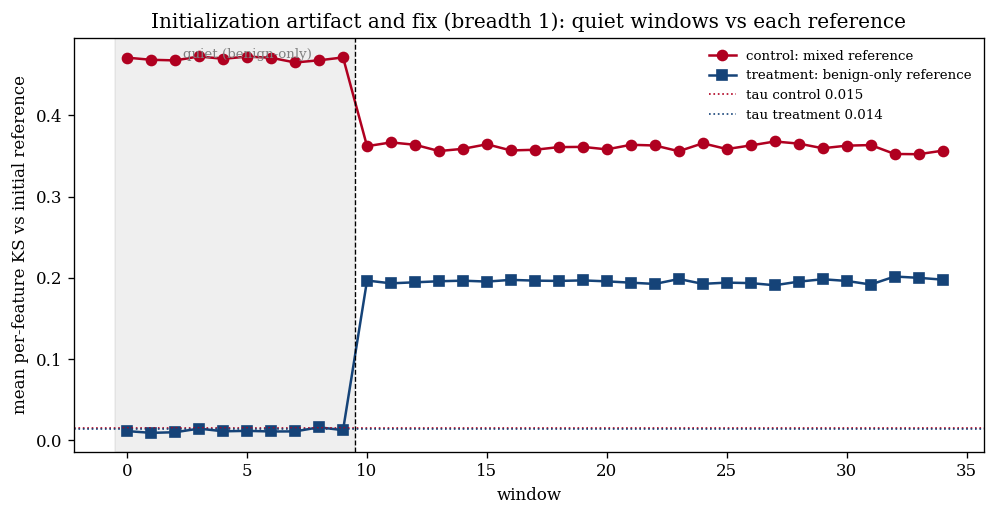

In [6]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                     'figure.dpi': 120, 'savefig.dpi': 300})
b_show = BREADTHS[0]
R = build_regime(attack_order[:b_show])
Xs, wins, is_drift = R['Xs'], R['windows'], R['is_drift']
Xtr = R['Xtr']
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(Xtr)); n_ref = int(REF_FRAC * len(Xtr))
REF_C = Xtr[perm[:n_ref]]
bpos = R['warm_benign_pos']; bperm = np.random.default_rng(SEED).permutation(len(bpos))
REF_T = Xtr[bpos[bperm[:len(bpos)//2]]]

res_b = next(r for r in results if r['breadth'] == b_show)
tau_c = res_b['arms']['control']['tau']; tau_t = res_b['arms']['treatment']['tau']
# static traces (fixed initial reference) — visualises the initialization offset
sc = [float(per_feature_ks(REF_C, Xs[a:b2]).mean()) for (a, b2) in wins]
st = [float(per_feature_ks(REF_T, Xs[a:b2]).mean()) for (a, b2) in wins]

fig, ax = plt.subplots(figsize=(8.4, 4.4))
w = np.arange(len(wins))
ax.plot(w, sc, 'o-', color='#B00020', label='control: mixed reference')
ax.plot(w, st, 's-', color='#154378', label='treatment: benign-only reference')
ax.axhline(tau_c, ls=':', color='#B00020', lw=1, label=f'tau control {tau_c:.3f}')
ax.axhline(tau_t, ls=':', color='#154378', lw=1, label=f'tau treatment {tau_t:.3f}')
onset = res_b['onset_window']
ax.axvspan(-0.5, onset - 0.5, color='grey', alpha=0.12)
ax.text(onset / 2, ax.get_ylim()[1] * 0.95, 'quiet (benign-only)',
        ha='center', fontsize=8, color='grey')
ax.axvline(onset - 0.5, color='black', lw=0.8, ls='--')
ax.set_xlabel('window'); ax.set_ylabel('mean per-feature KS vs initial reference')
ax.set_title(f'Initialization artifact and fix (breadth {b_show}): '
             'quiet windows vs each reference')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
path('reports', 'figures').mkdir(parents=True, exist_ok=True)
for ext in ['png', 'pdf']:
    fig.savefig(path('reports', 'figures') / f'26_benign_reference_trace.{ext}')
plt.show()

## 7. Gates (A3.4) and verdict

In [7]:
g_ctrl = any(r['arms']['control']['fa_point'] > FA_POINT_MAX for r in results)
g_fa = all((r['arms']['treatment']['fa_point'] <= FA_POINT_MAX)
           and (r['arms']['treatment']['fa_ci'][1] <= FA_CI_MAX) for r in results)
g_det = all((r['arms']['treatment']['onset_latency'] is not None)
            and (r['arms']['treatment']['onset_latency'] <= L_MAX)
            and (r['arms']['treatment']['recall_t2500']
                 >= r['arms']['control']['recall_t2500'] - RECALL_MARGIN)
            for r in results)

verdict = ('ARTIFACT-FIXED' if (g_ctrl and g_fa and g_det) else
           'ARTIFACT-NOT-REPRODUCED' if not g_ctrl else
           'FIX-COSTS-SENSITIVITY' if (g_fa and not g_det) else
           'FIX-INSUFFICIENT')

rows = []
for r in results:
    for arm in ('control', 'treatment'):
        a = r['arms'][arm]
        rows.append(dict(breadth=r['breadth'], arm=arm, tau=round(a['tau'], 4),
                         fa=f"{a['fa_k']}/{a['fa_n']}",
                         fa_point=round(a['fa_point'], 3),
                         fa_ci_hi=round(a['fa_ci'][1], 3),
                         onset_latency=a['onset_latency'],
                         t250_recall=round(a['recall_t250'], 3),
                         t2500_recall=round(a['recall_t2500'], 3),
                         t250_labels=a['labels_t250']))
tab = pd.DataFrame(rows)
display(tab)
path('reports', 'tables').mkdir(parents=True, exist_ok=True)
tab.to_csv(path('reports', 'tables') / '26_benign_reference_trigger.csv', index=False)

print('=' * 76)
print('BENIGN-ONLY REFERENCE TRIGGER — A3 VERDICT')
print('=' * 76)
print(f'  G-CTRL (artifact reproduces in control): {g_ctrl}')
print(f'  G-FA   (treatment FA <= {FA_POINT_MAX} point / {FA_CI_MAX} CI-hi, all breadths): {g_fa}')
print(f'  G-DET  (latency <= {L_MAX} and recall within {RECALL_MARGIN}, all breadths): {g_det}')
print(f'  tau sensitivity (treatment): bootstrap vs contiguous per breadth: '
      f"{[(r['breadth'], round(r['tau_treatment_bootstrap'],4), round(r['tau_treatment_contiguous'],4)) for r in results]}")
print('-' * 76)
print(f'--> VERDICT: {verdict}')

,breadth,arm,tau,fa,fa_point,fa_ci_hi,onset_latency,t250_recall,t2500_recall,t250_labels
0,1,control,0.0155,1/10,0.1,0.404,0,0.852,0.868,500
1,1,treatment,0.0137,2/10,0.2,0.510,0,0.800,0.819,1000
2,2,control,0.0147,1/10,0.1,0.404,0,0.889,0.914,2000
3,2,treatment,0.0142,2/10,0.2,0.510,0,0.857,0.887,2000
4,4,control,0.0128,2/10,0.2,0.510,0,0.817,0.842,1750
5,4,treatment,0.0121,3/10,0.3,0.603,0,0.802,0.838,2250


BENIGN-ONLY REFERENCE TRIGGER — A3 VERDICT
  G-CTRL (artifact reproduces in control): True
  G-FA   (treatment FA <= 0.1 point / 0.2 CI-hi, all breadths): False
  G-DET  (latency <= 1 and recall within 0.05, all breadths): True
  tau sensitivity (treatment): bootstrap vs contiguous per breadth: [(1, 0.0137, 0.0134), (2, 0.0142, 0.0129), (4, 0.0121, 0.0138)]
----------------------------------------------------------------------------
--> VERDICT: FIX-INSUFFICIENT


## 8. Save summary + log (set free decision/finding IDs first)

In [8]:
summary = dict(
    notebook='26_benign_reference_trigger', prereg='A3',
    generated=str(date.today()), seed=SEED,
    construction='nb21 (D039) verbatim; two monitor arms on identical streams',
    breadths=BREADTHS, window_size=WINDOW_SIZE, quiet_windows=QUIET_WINDOWS,
    n_cal_boot=N_CAL_BOOT,
    gates=dict(G_CTRL=bool(g_ctrl), G_FA=bool(g_fa), G_DET=bool(g_det)),
    per_breadth=[dict(breadth=r['breadth'], seen=r['seen'],
                      onset=r['onset_window'],
                      never_recall=r['never_recall'], slide_recall=r['slide_recall'],
                      tau_boot=r['tau_treatment_bootstrap'],
                      tau_contig=r['tau_treatment_contiguous'],
                      control=r['arms']['control'], treatment=r['arms']['treatment'])
                 for r in results],
    verdict=verdict)
out = path('data', 'processed') / 'phase7_26_benign_reference_trigger.json'
with open(out, 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print('Saved', out)

# Set the next free IDs (decisions log had D031/D032 collisions — check first):
# log_decision -> paste the A3 design text under the next free D-ID.
# log_finding(
#     finding_id='F0XX',
#     title='Benign-only monitor reference: <verdict>',
#     context='07_phase5_adaptation/26_benign_reference_trigger',
#     what_we_did='Two-arm re-run of the nb21 breadth sweep on identical streams/'
#                 'detectors: control (mixed reference, nb21 verbatim) vs treatment '
#                 '(benign-only reference + bootstrap benign calibration). A3 gates.',
#     what_we_found='<per-breadth FA control vs treatment, latencies, t2500 recalls, '
#                   'tau sensitivity>',
#     why_it_matters='Converts the nb21/22 selectivity limitation into diagnosed -> '
#                    'fixed -> re-validated; unblocks notebook 27 (regime-gate '
#                    're-confirmation under the fixed trigger) for paper #2.',
# )

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase7_26_benign_reference_trigger.json


## 9. Routing

- **ARTIFACT-FIXED** → build notebook 27: re-run the nb22 corrected-gate
  confirmation (4 seeds) with the treatment monitor, fresh pre-registration —
  the paper-#2 trigger section is then complete.
- **FIX-COSTS-SENSITIVITY** → report both arms honestly; the trade-off itself
  is a paper-#2 result (selectivity vs latency under reference composition).
- **ARTIFACT-NOT-REPRODUCED** → the nb21 FA rates came from something else;
  investigate the trigger traces (Section 6 figure) before touching anything.